📌 Device: cuda
   GPU: Tesla P100-PCIE-16GB
   Memory: 15.9 GB

📂 خواندن فایل ویژگی‌ها...
   تعداد کل تصاویر: 202,599
   تعداد ویژگی‌ها: 40
   Black_Hair: 48,472 (23.9%)
   Brown_Hair: 41,572 (20.5%)
   Smiling: 97,669 (48.2%)

🔍 فیلتر: تصاویر دارای Black_Hair یا Brown_Hair ...
   بعد از فیلتر: 88,908 تصویر

📊 توزیع ویژگی‌ها بعد از فیلتر:
   فقط Black_Hair:  47,336
   فقط Brown_Hair:  40,436
   هر دو:           1,136
   Smiling:          43,654 (49.1%)

⚖️ بالانس بین Black_Hair و Brown_Hair ...
   Black_Hair only: 47,336
   Brown_Hair only: 40,436
   Both:            1,136
   → بالانس به: 40,436 از هر کلاس
   تعداد نهایی: 82,008

📊 آمار نهایی دیتاست:
   Black_Hair=1: 41,572 (50.7%)
   Brown_Hair=1: 41,572 (50.7%)
   Smiling=1:    40,358 (49.2%)

✅ DataLoader آماده:
   تعداد نمونه: 82,008
   تعداد بچ: 320
   Batch size: 256

🖼️ نمایش نمونه تصاویر با ویژگی‌ها:
   Image batch shape: torch.Size([256, 3, 64, 64])
   Label batch shape: torch.Size([256, 3])
   Label sample[0]: [1.0, 0.0, 0.0]

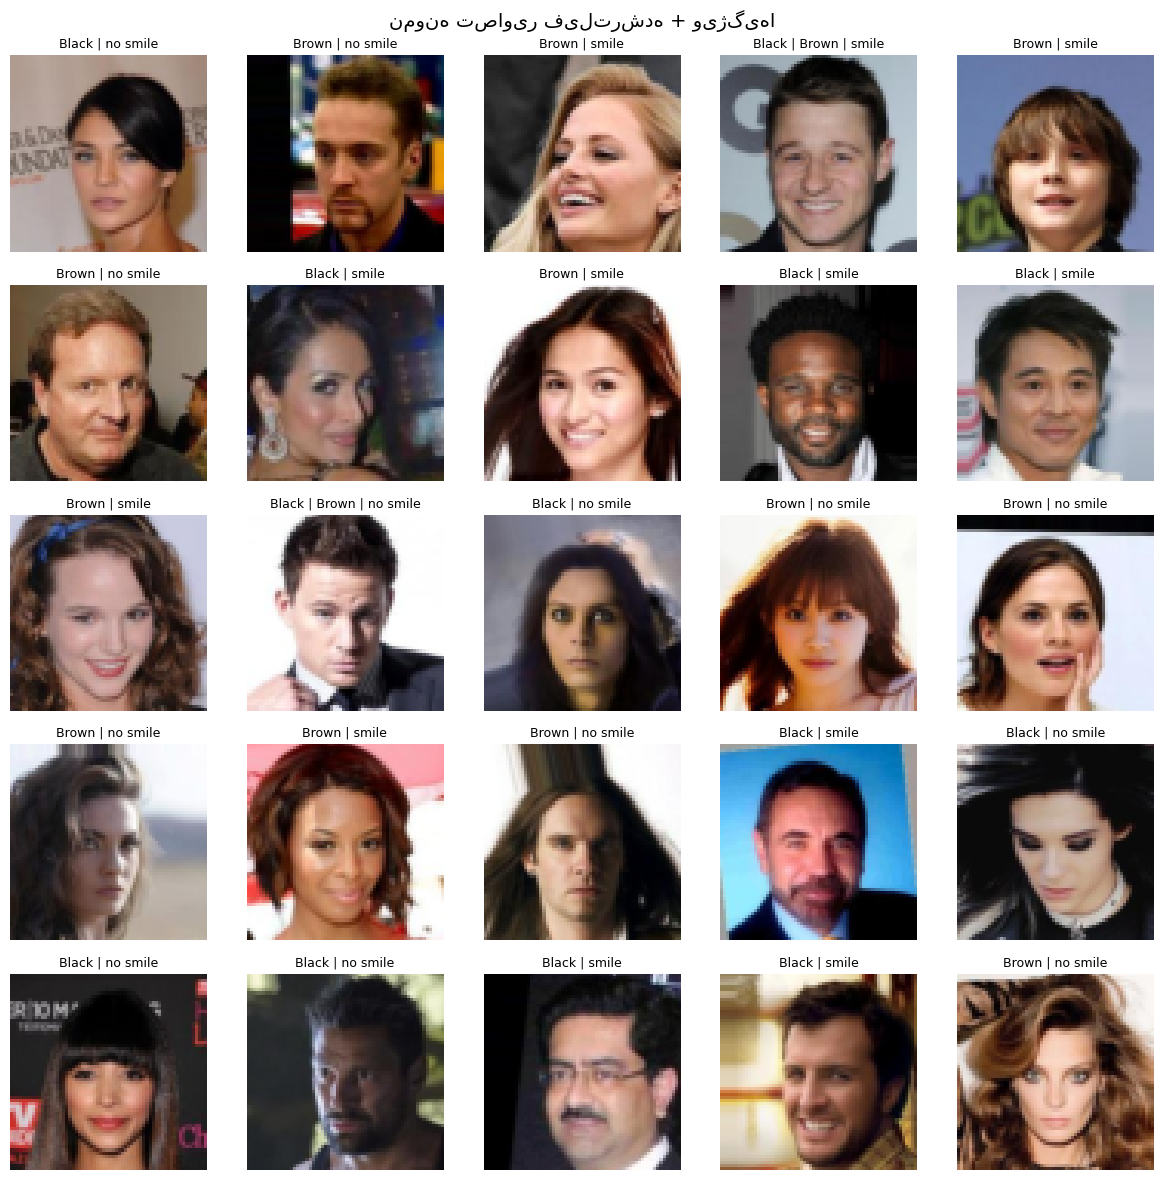


 سلول ۱ کامل شد — داده آماده است


In [14]:
# ============================================================
#  سلول ۱: تنظیمات، بارگذاری داده و پیش‌پردازش
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision
import torchvision.transforms as transforms
from torchvision.models import inception_v3
import torch.nn.functional as F
from scipy import linalg

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# ---------- Seed ----------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# ---------- Config ----------
CONFIG = {
    # مسیرها
    'img_dir': '/kaggle/input/datasets/jessicali9530/celeba-dataset/img_align_celeba/img_align_celeba',
    'attr_path': '/kaggle/input/datasets/jessicali9530/celeba-dataset/list_attr_celeba.csv',

    # تصویر
    'image_size': 64,
    'nc': 3,

    # مدل
    'nz': 100,
    'n_classes': 3,        # [Black_Hair, Brown_Hair, Smiling]
    'ngf': 32,
    'ndf': 32,

    # آموزش
    'batch_size': 256,
    'num_epochs': 30,
    'lr_g': 0.0002,
    'lr_d': 0.0004,
    'beta1': 0.5,
    'beta2': 0.999,
    'real_label_val': 0.9,
    'fake_label_val': 0.0,

    # FID
    'fid_samples': 1024,
    'fid_batch_size': 64,
    'fid_interval': 5,       # هر ۵ epoch

    # نمایش
    'sample_interval': 5,    # هر ۵ epoch نمونه ذخیره بشه
    'num_display': 25,       # تعداد تصاویر نمایشی (5x5)

    # سایر
    'max_samples': None,     # None = استفاده از همه داده‌های فیلترشده
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"📌 Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

# ---------- Transforms ----------
transform = transforms.Compose([
    transforms.Resize(CONFIG['image_size']),
    transforms.CenterCrop(CONFIG['image_size']),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# ---------- خواندن CSV ویژگی‌ها ----------
print("\n📂 خواندن فایل ویژگی‌ها...")
attr_df = pd.read_csv(CONFIG['attr_path'])
print(f"   تعداد کل تصاویر: {len(attr_df):,}")
print(f"   تعداد ویژگی‌ها: {len(attr_df.columns) - 1}")

# تبدیل -1 به 0
attr_columns = [c for c in attr_df.columns if c != 'image_id']
attr_df[attr_columns] = (attr_df[attr_columns] + 1) // 2  # -1→0, 1→1

# بررسی وجود ویژگی‌های مورد نیاز
required_attrs = ['Black_Hair', 'Brown_Hair', 'Smiling']
for attr in required_attrs:
    assert attr in attr_df.columns, f"❌ ویژگی '{attr}' در CSV وجود ندارد!"
    count = attr_df[attr].sum()
    print(f"   {attr}: {count:,} ({count/len(attr_df)*100:.1f}%)")

# ---------- فیلتر: فقط Black_Hair OR Brown_Hair ----------
print("\n🔍 فیلتر: تصاویر دارای Black_Hair یا Brown_Hair ...")
mask = (attr_df['Black_Hair'] == 1) | (attr_df['Brown_Hair'] == 1)
filtered_df = attr_df[mask].copy()
print(f"   بعد از فیلتر: {len(filtered_df):,} تصویر")

# آمار ترکیبات
black_only = (filtered_df['Black_Hair'] == 1) & (filtered_df['Brown_Hair'] == 0)
brown_only = (filtered_df['Black_Hair'] == 0) & (filtered_df['Brown_Hair'] == 1)
both_hair  = (filtered_df['Black_Hair'] == 1) & (filtered_df['Brown_Hair'] == 1)

print(f"\n📊 توزیع ویژگی‌ها بعد از فیلتر:")
print(f"   فقط Black_Hair:  {black_only.sum():,}")
print(f"   فقط Brown_Hair:  {brown_only.sum():,}")
print(f"   هر دو:           {both_hair.sum():,}")
print(f"   Smiling:          {filtered_df['Smiling'].sum():,} ({filtered_df['Smiling'].mean()*100:.1f}%)")

# ---------- بالانس کلاس‌ها ----------
print("\n⚖️ بالانس بین Black_Hair و Brown_Hair ...")
black_indices = filtered_df[black_only].index.tolist()
brown_indices = filtered_df[brown_only].index.tolist()
both_indices  = filtered_df[both_hair].index.tolist()

min_count = min(len(black_indices), len(brown_indices))
print(f"   Black_Hair only: {len(black_indices):,}")
print(f"   Brown_Hair only: {len(brown_indices):,}")
print(f"   Both:            {len(both_indices):,}")
print(f"   → بالانس به: {min_count:,} از هر کلاس")

random.shuffle(black_indices)
random.shuffle(brown_indices)
random.shuffle(both_indices)

selected_indices = black_indices[:min_count] + brown_indices[:min_count] + both_indices
random.shuffle(selected_indices)

# برش از dataframe
balanced_df = attr_df.loc[selected_indices].reset_index(drop=True)
print(f"   تعداد نهایی: {len(balanced_df):,}")

if CONFIG['max_samples'] and len(balanced_df) > CONFIG['max_samples']:
    balanced_df = balanced_df.sample(n=CONFIG['max_samples'], random_state=42).reset_index(drop=True)
    print(f"   محدود شده به: {len(balanced_df):,}")

# آمار نهایی
print(f"\n📊 آمار نهایی دیتاست:")
print(f"   Black_Hair=1: {balanced_df['Black_Hair'].sum():,} ({balanced_df['Black_Hair'].mean()*100:.1f}%)")
print(f"   Brown_Hair=1: {balanced_df['Brown_Hair'].sum():,} ({balanced_df['Brown_Hair'].mean()*100:.1f}%)")
print(f"   Smiling=1:    {balanced_df['Smiling'].sum():,} ({balanced_df['Smiling'].mean()*100:.1f}%)")

# ---------- Dataset کلاس ----------
class ConditionalCelebA(Dataset):
    """دیتاست CelebA با بردار ویژگی ۳ تایی [Black_Hair, Brown_Hair, Smiling]"""
    
    def __init__(self, dataframe, img_dir, transform=None):
        self.df = dataframe
        self.img_dir = img_dir
        self.transform = transform
        self.attr_names = ['Black_Hair', 'Brown_Hair', 'Smiling']
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # لود تصویر
        img_path = os.path.join(self.img_dir, row['image_id'])
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
        
        # بردار ویژگی
        label_vector = torch.tensor(
            [row[attr] for attr in self.attr_names],
            dtype=torch.float32
        )
        
        return image, label_vector

# ---------- ساخت DataLoader ----------
dataset = ConditionalCelebA(balanced_df, CONFIG['img_dir'], transform=transform)
# ===== DataLoader بهینه‌شده =====
train_loader = DataLoader(
    dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=2,          # ← Kaggle با 2 عالیه، 0 خیلی کنده
    pin_memory=True,        # ← انتقال سریع‌تر به GPU
    drop_last=True,         # ← جلوگیری از بچ‌های کوچک آخری
    persistent_workers=True # ← workerها زنده می‌مونن بین epochها
)

print(f"\n✅ DataLoader آماده:")
print(f"   تعداد نمونه: {len(dataset):,}")
print(f"   تعداد بچ: {len(train_loader):,}")
print(f"   Batch size: {CONFIG['batch_size']}")

# ---------- نمایش نمونه‌ها ----------
print("\n🖼️ نمایش نمونه تصاویر با ویژگی‌ها:")

sample_imgs, sample_labels = next(iter(train_loader))
print(f"   Image batch shape: {sample_imgs.shape}")
print(f"   Label batch shape: {sample_labels.shape}")
print(f"   Label sample[0]: {sample_labels[0].tolist()} → Black={int(sample_labels[0][0])}, Brown={int(sample_labels[0][1])}, Smile={int(sample_labels[0][2])}")

fig, axes = plt.subplots(5, 5, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    img = sample_imgs[i].permute(1, 2, 0).numpy() * 0.5 + 0.5
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    lbl = sample_labels[i]
    title_parts = []
    if lbl[0] == 1: title_parts.append("Black")
    if lbl[1] == 1: title_parts.append("Brown")
    if lbl[2] == 1: title_parts.append("smile")
    else: title_parts.append("no smile")
    ax.set_title(" | ".join(title_parts), fontsize=9)
    ax.axis('off')
plt.suptitle("نمونه تصاویر فیلترشده + ویژگی‌ها", fontsize=14)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(" سلول ۱ کامل شد — داده آماده است")
print("="*60)


In [15]:
# ============================================================
#  سلول ۲: معماری Conditional Generator و Discriminator
# ============================================================

def weights_init(m):
    """مقداردهی اولیه وزن‌ها — DCGAN style"""
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


# ---------- Conditional Generator ----------
class ConditionalGenerator(nn.Module):
    """
    Generator با روش Concatenation
    ورودی: z (nz=100) ⊕ y (n_classes=3) = 103 → reshape به (103, 1, 1)
    خروجی: تصویر (3, 64, 64)
    """
    def __init__(self, nz, n_classes, ngf, nc):
        super().__init__()
        self.nz = nz
        self.n_classes = n_classes
        
        input_dim = nz + n_classes  # 100 + 3 = 103
        
        self.main = nn.Sequential(
            # ورودی: (103, 1, 1) → (ngf*8, 4, 4)
            nn.ConvTranspose2d(input_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            
            # (ngf*8, 4, 4) → (ngf*4, 8, 8)
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            
            # (ngf*4, 8, 8) → (ngf*2, 16, 16)
            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            
            # (ngf*2, 16, 16) → (ngf, 32, 32)
            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            
            # (ngf, 32, 32) → (nc, 64, 64)
            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh(),
        )
    
    def forward(self, z, labels):
        """
        z:      (B, nz, 1, 1) یا (B, nz)
        labels: (B, n_classes)
        """
        # اطمینان از شکل z
        if z.dim() == 2:
            z = z.unsqueeze(-1).unsqueeze(-1)  # (B, nz) → (B, nz, 1, 1)
        
        # labels → (B, n_classes, 1, 1)
        label_input = labels.unsqueeze(-1).unsqueeze(-1)  # (B, 3, 1, 1)
        
        # concat
        gen_input = torch.cat([z, label_input], dim=1)  # (B, 103, 1, 1)
        
        return self.main(gen_input)


# ---------- Conditional Discriminator ----------
class ConditionalDiscriminator(nn.Module):
    """
    Discriminator با روش Concatenation
    ورودی: image (3, 64, 64) ⊕ label_map (3, 64, 64) = (6, 64, 64)
    خروجی: عدد احتمال (واقعی/جعلی)
    
    label_map: هر ویژگی به یک کانال کامل 64×64 تبدیل میشه
               (مقدار ثابت 0 یا 1 در کل پیکسل‌ها)
    """
    def __init__(self, nc, n_classes, ndf):
        super().__init__()
        self.n_classes = n_classes
        
        input_channels = nc + n_classes  # 3 + 3 = 6
        
        self.main = nn.Sequential(
            # ورودی: (6, 64, 64) → (ndf, 32, 32)
            nn.Conv2d(input_channels, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            
            # (ndf, 32, 32) → (ndf*2, 16, 16)
            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),
            
            # (ndf*2, 16, 16) → (ndf*4, 8, 8)
            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),
            
            # (ndf*4, 8, 8) → (ndf*8, 4, 4)
            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),
            
            # (ndf*8, 4, 4) → (1, 1, 1)
            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )
    
    def forward(self, img, labels):
        """
        img:    (B, 3, 64, 64)
        labels: (B, n_classes)
        """
        # labels → label_map: (B, n_classes, 64, 64)
        label_map = labels.unsqueeze(-1).unsqueeze(-1)  # (B, 3, 1, 1)
        label_map = label_map.expand(-1, -1, img.size(2), img.size(3))  # (B, 3, 64, 64)
        
        # concat
        d_input = torch.cat([img, label_map], dim=1)  # (B, 6, 64, 64)
        
        return self.main(d_input).view(-1)


# ---------- ساخت مدل‌ها ----------
netG = ConditionalGenerator(
    nz=CONFIG['nz'],
    n_classes=CONFIG['n_classes'],
    ngf=CONFIG['ngf'],
    nc=CONFIG['nc']
).to(DEVICE)

netD = ConditionalDiscriminator(
    nc=CONFIG['nc'],
    n_classes=CONFIG['n_classes'],
    ndf=CONFIG['ndf']
).to(DEVICE)

# مقداردهی اولیه
netG.apply(weights_init)
netD.apply(weights_init)

# ---------- خلاصه مدل‌ها ----------
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 60)
print("🏗️ Conditional Generator")
print("=" * 60)
print(f"   ورودی: z({CONFIG['nz']}) + y({CONFIG['n_classes']}) = {CONFIG['nz'] + CONFIG['n_classes']}")
print(f"   خروجی: ({CONFIG['nc']}, {CONFIG['image_size']}, {CONFIG['image_size']})")
print(f"   پارامترها: {count_params(netG):,}")
print()
print(netG)

print("\n" + "=" * 60)
print("🏗️ Conditional Discriminator")
print("=" * 60)
print(f"   ورودی: img({CONFIG['nc']}, 64, 64) + label_map({CONFIG['n_classes']}, 64, 64) = ({CONFIG['nc'] + CONFIG['n_classes']}, 64, 64)")
print(f"   خروجی: عدد احتمال (scalar)")
print(f"   پارامترها: {count_params(netD):,}")
print()
print(netD)

print(f"\n📊 مجموع پارامترها: {count_params(netG) + count_params(netD):,}")

# ---------- تست سریع ----------
print("\n🧪 تست سریع forward pass ...")
test_z = torch.randn(4, CONFIG['nz'], 1, 1, device=DEVICE)
test_labels = torch.randint(0, 2, (4, CONFIG['n_classes']), dtype=torch.float32, device=DEVICE)

with torch.no_grad():
    fake_test = netG(test_z, test_labels)
    d_test = netD(fake_test, test_labels)

print(f"   Generator output: {fake_test.shape}")
print(f"   Discriminator output: {d_test.shape} → values: {d_test.tolist()}")
print("   ✅ Forward pass موفق!")

print("\n" + "="*60)
print("✅ سلول ۲ کامل شد — معماری‌ها آماده هستند")
print("="*60)


🏗️ Conditional Generator
   ورودی: z(100) + y(3) = 103
   خروجی: (3, 64, 64)
   پارامترها: 1,112,512

ConditionalGenerator(
  (main): Sequential(
    (0): ConvTranspose2d(103, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12):

In [16]:
# ============================================================
#  سلول ۳: Loss, Optimizer, FID Calculator
# ============================================================

# ---------- Loss & Optimizers ----------
criterion = nn.BCELoss()

optimizerG = optim.Adam(netG.parameters(), lr=CONFIG['lr_g'], betas=(CONFIG['beta1'], CONFIG['beta2']))
optimizerD = optim.Adam(netD.parameters(), lr=CONFIG['lr_d'], betas=(CONFIG['beta1'], CONFIG['beta2']))

print("⚙️ تنظیمات آموزش:")
print(f"   Loss: BCELoss + Label Smoothing (real={CONFIG['real_label_val']}, fake={CONFIG['fake_label_val']})")
print(f"   Optimizer G: Adam(lr={CONFIG['lr_g']}, beta1={CONFIG['beta1']})")
print(f"   Optimizer D: Adam(lr={CONFIG['lr_d']}, beta1={CONFIG['beta1']})")

# ---------- Fixed Noise برای نمایش پیشرفت ----------
# 25 نمونه برای گرید 5×5 — با لیبل‌های مختلف
fixed_noise = torch.randn(CONFIG['num_display'], CONFIG['nz'], 1, 1, device=DEVICE)

# ساخت لیبل‌های متنوع برای نمایش (5 ترکیب × 5 نمونه)
display_labels_list = [
    [1, 0, 1],  # Black + Smile
    [1, 0, 0],  # Black + No Smile
    [0, 1, 1],  # Brown + Smile
    [0, 1, 0],  # Brown + No Smile
    [1, 1, 1],  # Both + Smile
]
fixed_labels = torch.tensor(
    display_labels_list * 5,  # 5 ترکیب × 5 = 25
    dtype=torch.float32, device=DEVICE
)
# مرتب‌سازی: هر ردیف یک ترکیب ویژگی
fixed_labels = fixed_labels[:CONFIG['num_display']]

print(f"\n🎲 Fixed noise shape: {fixed_noise.shape}")
print(f"📋 Fixed labels shape: {fixed_labels.shape}")
print(f"   ترکیبات ویژگی برای نمایش:")
label_names = ['Black_Hair', 'Brown_Hair', 'Smiling']
for i, lbl in enumerate(display_labels_list):
    active = [label_names[j] for j in range(3) if lbl[j] == 1]
    print(f"   ردیف {i+1}: {' + '.join(active) if active else 'None'}")

# ---------- FID Calculator ----------
class FIDCalculator:
    """محاسبه FID Score با InceptionV3 — سازگار با Conditional GAN"""
    
    def __init__(self, device, batch_size=64):
        self.device = device
        self.batch_size = batch_size
        self.model = None
    
    def _load_model(self):
        if self.model is not None:
            return
        print("   📥 بارگذاری InceptionV3 ...")
        self.model = inception_v3(pretrained=True, transform_input=False)
        self.model.fc = nn.Identity()
        self.model.eval()
        self.model.to(self.device)
    
    def _preprocess(self, images):
        """تبدیل تصاویر [-1,1] به فرمت Inception: resize 299 + normalize"""
        images = (images + 1) / 2  # [-1,1] → [0,1]
        images = F.interpolate(images, size=(299, 299), mode='bilinear', align_corners=False)
        # Inception normalization
        mean = torch.tensor([0.485, 0.456, 0.406], device=images.device).view(1, 3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225], device=images.device).view(1, 3, 1, 1)
        images = (images - mean) / std
        return images
    
    @torch.no_grad()
    def _get_features(self, images):
        images = self._preprocess(images)
        features = self.model(images)
        return features.cpu().numpy()
    
    @torch.no_grad()
    def compute_real_stats(self, dataloader, num_samples=1024):
        """محاسبه mu و sigma برای تصاویر واقعی"""
        self._load_model()
        print(f"   📊 محاسبه آمار تصاویر واقعی ({num_samples} نمونه) ...")
        all_feats = []
        remaining = num_samples
        
        for images, _ in dataloader:
            if remaining <= 0:
                break
            batch = min(images.size(0), remaining)
            images = images[:batch].to(self.device)
            feats = self._get_features(images)
            all_feats.append(feats)
            remaining -= batch
        
        all_feats = np.concatenate(all_feats)[:num_samples]
        mu = np.mean(all_feats, axis=0)
        sigma = np.cov(all_feats, rowvar=False)
        print(f"   ✅ آمار واقعی محاسبه شد — features shape: {all_feats.shape}")
        return mu, sigma
    
    @torch.no_grad()
    def compute_fid(self, generator, real_mu, real_sigma, num_samples=1024):
        """محاسبه FID — با لیبل‌های رندوم"""
        self._load_model()
        generator.eval()
        all_feats = []
        remaining = num_samples
        
        while remaining > 0:
            batch = min(self.batch_size, remaining)
            noise = torch.randn(batch, CONFIG['nz'], 1, 1, device=self.device)
            random_labels = torch.randint(
                0, 2, (batch, CONFIG['n_classes']),
                dtype=torch.float32, device=self.device
            )
            fake = generator(noise, random_labels)
            feats = self._get_features(fake)
            all_feats.append(feats)
            remaining -= batch
        
        generator.train()
        all_feats = np.concatenate(all_feats)[:num_samples]
        gen_mu = np.mean(all_feats, axis=0)
        gen_sigma = np.cov(all_feats, rowvar=False)
        
        return self._frechet_dist(real_mu, real_sigma, gen_mu, gen_sigma)
    
    def _frechet_dist(self, mu1, sigma1, mu2, sigma2):
        diff = mu1 - mu2
        covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        return float(diff.dot(diff) + np.trace(sigma1 + sigma2 - 2 * covmean))


# ---------- محاسبه آمار واقعی ----------
fid_calc = FIDCalculator(DEVICE, batch_size=CONFIG['fid_batch_size'])
real_mu, real_sigma = fid_calc.compute_real_stats(train_loader, num_samples=CONFIG['fid_samples'])

print("\n" + "="*60)
print("✅ سلول ۳ کامل شد — Loss, Optimizer, FID آماده")
print("="*60)


⚙️ تنظیمات آموزش:
   Loss: BCELoss + Label Smoothing (real=0.9, fake=0.0)
   Optimizer G: Adam(lr=0.0002, beta1=0.5)
   Optimizer D: Adam(lr=0.0004, beta1=0.5)

🎲 Fixed noise shape: torch.Size([25, 100, 1, 1])
📋 Fixed labels shape: torch.Size([25, 3])
   ترکیبات ویژگی برای نمایش:
   ردیف 1: Black_Hair + Smiling
   ردیف 2: Black_Hair
   ردیف 3: Brown_Hair + Smiling
   ردیف 4: Brown_Hair
   ردیف 5: Black_Hair + Brown_Hair + Smiling
   📥 بارگذاری InceptionV3 ...
   📊 محاسبه آمار تصاویر واقعی (1024 نمونه) ...
   ✅ آمار واقعی محاسبه شد — features shape: (1024, 2048)

✅ سلول ۳ کامل شد — Loss, Optimizer, FID آماده


In [ ]:
# ============================================================
#  سلول ۴: حلقه آموزش Conditional GAN
# ============================================================

import time

# ذخیره تاریخچه
history = {
    'G_losses': [],
    'D_losses': [],
    'D_x': [],        # خروجی D روی واقعی
    'D_G_z1': [],     # خروجی D روی جعلی (قبل از آپدیت G)
    'D_G_z2': [],     # خروجی D روی جعلی (بعد از آپدیت G)
    'fid_scores': [],
    'fid_epochs': [],
    'epoch_G_losses': [],
    'epoch_D_losses': [],
}

# ذخیره تصاویر تولیدی
generated_samples = {}

print("=" * 60)
print("🚀 شروع آموزش Conditional GAN")
print("=" * 60)
print(f"   Epochs: {CONFIG['num_epochs']}")
print(f"   Batch size: {CONFIG['batch_size']}")
print(f"   Generator LR: {CONFIG['lr_g']}")
print(f"   Discriminator LR: {CONFIG['lr_d']}")
print(f"   Label Smoothing: real={CONFIG['real_label_val']}, fake={CONFIG['fake_label_val']}")
print(f"   Device: {DEVICE}")
print("=" * 60)

total_start = time.time()

for epoch in range(CONFIG['num_epochs']):
    epoch_start = time.time()
    
    epoch_G_loss = 0.0
    epoch_D_loss = 0.0
    epoch_D_x = 0.0
    epoch_D_G_z1 = 0.0
    epoch_D_G_z2 = 0.0
    num_batches = 0
    
    netG.train()
    netD.train()
    
    for i, (real_imgs, real_labels) in enumerate(train_loader):
        real_imgs = real_imgs.to(DEVICE)
        real_labels = real_labels.to(DEVICE)  # (B, 3)
        b_size = real_imgs.size(0)
        
        # ============ آموزش Discriminator ============
        netD.zero_grad()
        
        # --- Real ---
        label_real = torch.full((b_size,), CONFIG['real_label_val'], 
                                dtype=torch.float32, device=DEVICE)
        output_real = netD(real_imgs, real_labels)
        errD_real = criterion(output_real, label_real)
        errD_real.backward()
        D_x = output_real.mean().item()
        
        # --- Fake ---
        noise = torch.randn(b_size, CONFIG['nz'], 1, 1, device=DEVICE)
        fake_imgs = netG(noise, real_labels)
        
        label_fake = torch.full((b_size,), CONFIG['fake_label_val'],
                                dtype=torch.float32, device=DEVICE)
        output_fake = netD(fake_imgs.detach(), real_labels)
        errD_fake = criterion(output_fake, label_fake)
        errD_fake.backward()
        D_G_z1 = output_fake.mean().item()
        
        errD = errD_real + errD_fake
        optimizerD.step()
        
        # ============ آموزش Generator ============
        netG.zero_grad()
        
        label_g = torch.full((b_size,), 1.0, dtype=torch.float32, device=DEVICE)
        output_g = netD(fake_imgs, real_labels)
        errG = criterion(output_g, label_g)
        errG.backward()
        D_G_z2 = output_g.mean().item()
        
        optimizerG.step()
        
        # ذخیره آمار
        history['G_losses'].append(errG.item())
        history['D_losses'].append(errD.item())
        history['D_x'].append(D_x)
        history['D_G_z1'].append(D_G_z1)
        history['D_G_z2'].append(D_G_z2)
        
        epoch_G_loss += errG.item()
        epoch_D_loss += errD.item()
        epoch_D_x += D_x
        epoch_D_G_z1 += D_G_z1
        epoch_D_G_z2 += D_G_z2
        num_batches += 1
    
    # میانگین epoch
    avg_G = epoch_G_loss / num_batches
    avg_D = epoch_D_loss / num_batches
    avg_Dx = epoch_D_x / num_batches
    avg_DGz1 = epoch_D_G_z1 / num_batches
    avg_DGz2 = epoch_D_G_z2 / num_batches
    
    history['epoch_G_losses'].append(avg_G)
    history['epoch_D_losses'].append(avg_D)
    
    epoch_time = time.time() - epoch_start
    
    # پرینت وضعیت
    print(f"[{epoch+1:2d}/{CONFIG['num_epochs']}] "
          f"Loss_D: {avg_D:.4f} | Loss_G: {avg_G:.4f} | "
          f"D(x): {avg_Dx:.3f} | D(G(z)): {avg_DGz1:.3f}/{avg_DGz2:.3f} | "
          f"⏱ {epoch_time:.0f}s")
    
    # ===== تولید نمونه + FID هر N epoch =====
    if (epoch + 1) % CONFIG['sample_interval'] == 0 or (epoch + 1) == CONFIG['num_epochs']:
        
        # تولید نمونه با fixed_noise و fixed_labels
        netG.eval()
        with torch.no_grad():
            fake_samples = netG(fixed_noise, fixed_labels).cpu()
        netG.train()
        generated_samples[epoch + 1] = fake_samples
        
        # نمایش
        fig, axes = plt.subplots(5, 5, figsize=(12, 12))
        for idx, ax in enumerate(axes.flat):
            img = fake_samples[idx].permute(1, 2, 0).numpy() * 0.5 + 0.5
            img = np.clip(img, 0, 1)
            ax.imshow(img)
            lbl = fixed_labels[idx].cpu()
            parts = []
            if lbl[0] == 1: parts.append("Blk")
            if lbl[1] == 1: parts.append("Brn")
            if lbl[2] == 1: parts.append("😊")
            else: parts.append("😐")
            ax.set_title(" ".join(parts), fontsize=9)
            ax.axis('off')
        plt.suptitle(f"Epoch {epoch+1} — Generated Samples", fontsize=14)
        plt.tight_layout()
        plt.show()
    
    # ===== FID =====
    if (epoch + 1) % CONFIG['fid_interval'] == 0 or (epoch + 1) == CONFIG['num_epochs']:
        print(f"   📊 محاسبه FID ...")
        fid_score = fid_calc.compute_fid(netG, real_mu, real_sigma, 
                                          num_samples=CONFIG['fid_samples'])
        history['fid_scores'].append(fid_score)
        history['fid_epochs'].append(epoch + 1)
        print(f"   📈 FID Score @ Epoch {epoch+1}: {fid_score:.2f}")

total_time = time.time() - total_start
print("\n" + "=" * 60)
print(f"✅ آموزش تمام شد! — کل زمان: {total_time/60:.1f} دقیقه")
print(f"   بهترین FID: {min(history['fid_scores']):.2f} (Epoch {history['fid_epochs'][np.argmin(history['fid_scores'])]})")
print("=" * 60)


🚀 شروع آموزش Conditional GAN
   Epochs: 30
   Batch size: 256
   Generator LR: 0.0002
   Discriminator LR: 0.0004
   Label Smoothing: real=0.9, fake=0.0
   Device: cuda
